<a href="https://colab.research.google.com/github/seongwoojang1123/Effusion-OSA-TMD/blob/main/2_data_initial_analyze_Effusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path
import matplotlib.patheffects as pe
from math import ceil

file_path = '/content/drive/MyDrive/Effusion OSA TMD/20250831_Effusion_TMD_Pain_Data.xlsx'

df = pd.read_excel(file_path, sheet_name='20250830_20250829_20250226_2024')

result variable Distribution

Effusion
1    0.696833
0    0.303167
Name: proportion, dtype: float64


/tmp/ipython-input-1422855563.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effusion', palette="Set2")


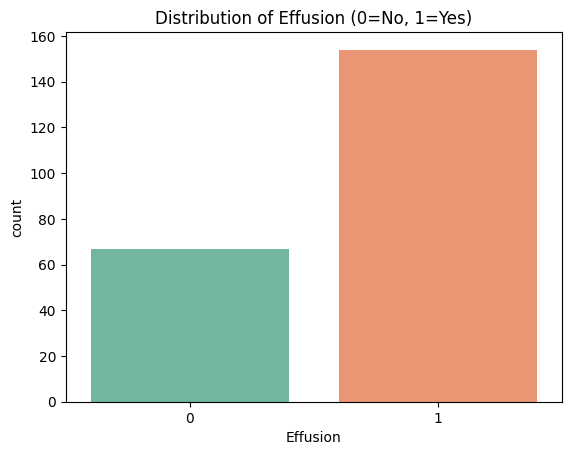

In [ ]:
print(df['Effusion'].value_counts(normalize=True))

sns.countplot(data=df, x='Effusion', palette="Set2")
plt.title("Distribution of Effusion (0=No, 1=Yes)")
plt.show()

/tmp/ipython-input-4268879368.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Effusion grade', palette="Set3")


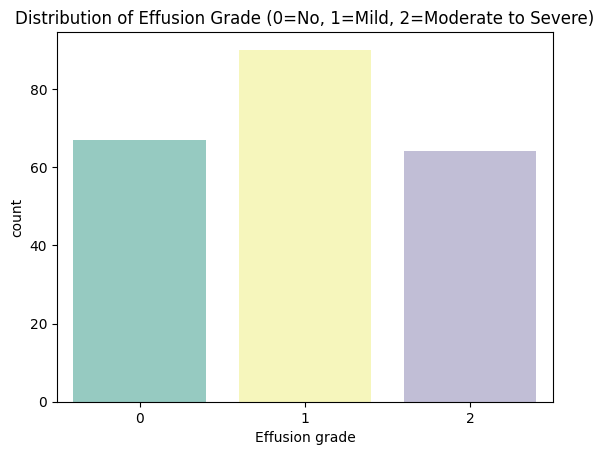

In [ ]:
sns.countplot(data=df, x='Effusion grade', palette="Set3")
plt.title("Distribution of Effusion Grade (0=No, 1=Mild, 2=Moderate to Severe)")
plt.show()

Key continuous variables Distribution & Effusion Group Boxplot

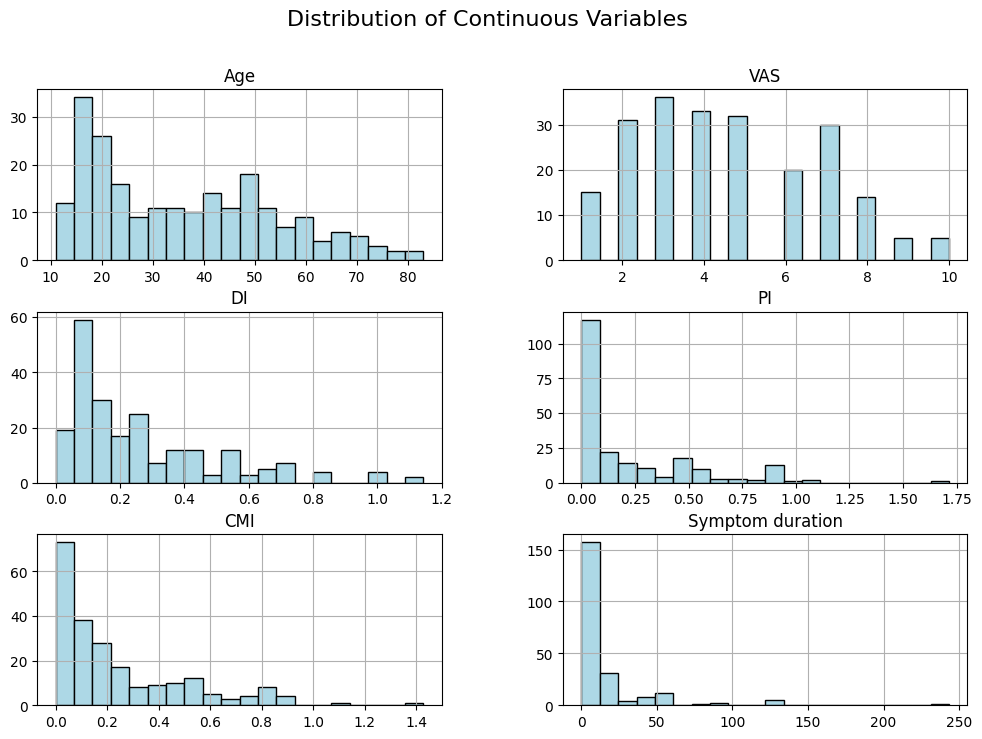

In [ ]:
cont_vars = ['Age','VAS','DI','PI','CMI','Symptom duration']

df[cont_vars].hist(bins=20, figsize=(12,8), color="lightblue", edgecolor="black")
plt.suptitle("Distribution of Continuous Variables", fontsize=16)
plt.show()

/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
/tmp/ipython-input-3329116239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

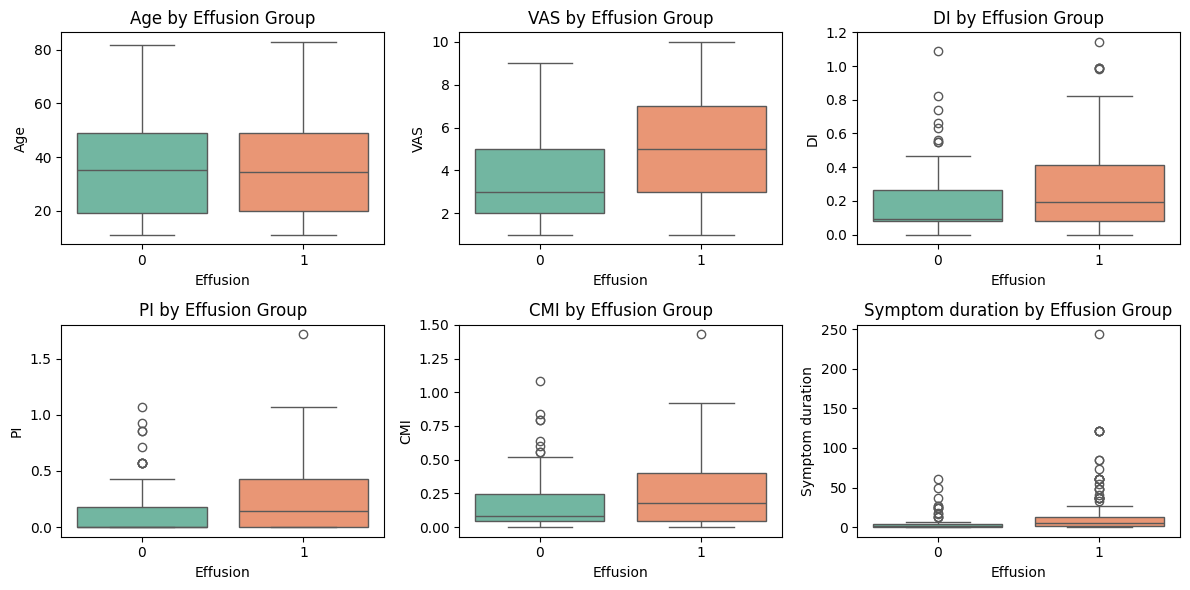

In [ ]:
plt.figure(figsize=(12,6))
for i, col in enumerate(cont_vars, 1):
    plt.subplot(2,3,i)
    sns.boxplot(data=df, x='Effusion', y=col, palette="Set2")
    plt.title(f"{col} by Effusion Group")
plt.tight_layout()
plt.show()

Effusion vs categorical variable

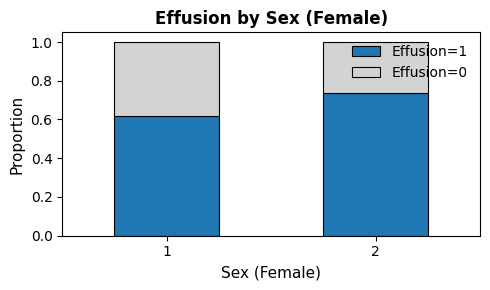

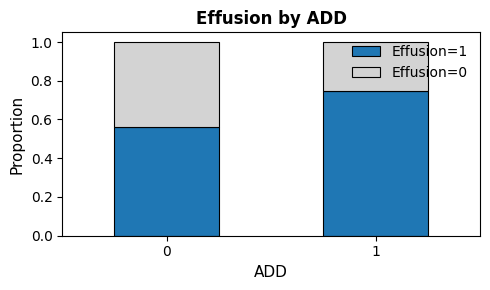

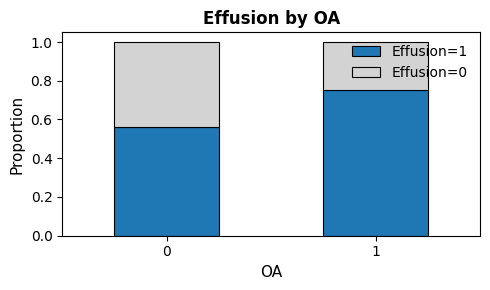

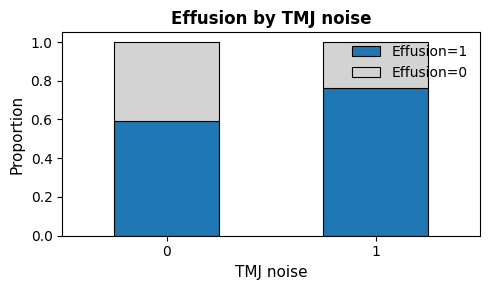

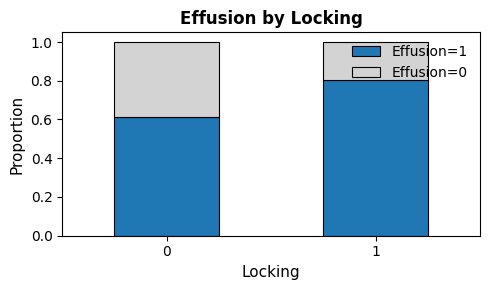

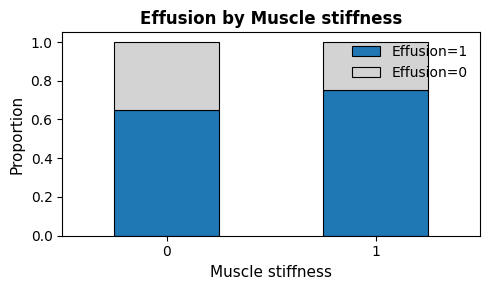

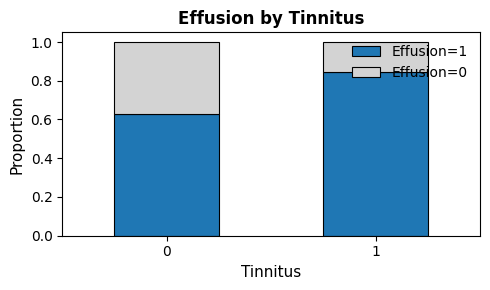

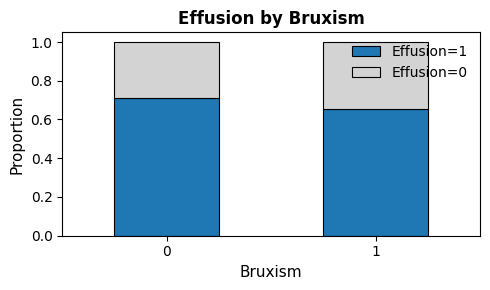

In [ ]:

cat_vars = ['Sex (Female)', 'ADD','OA','TMJ noise','Locking',
            'Muscle stiffness','Tinnitus','Bruxism']

for col in cat_vars:
    ct = pd.crosstab(df[col], df['Effusion'], normalize='index')


    ct = ct[[1,0]]

    # plot
    ax = ct.plot(kind='bar', stacked=True, figsize=(5,3),
                 color=["#1f77b4", "lightgray"],  # 1=컬러, 0=회색
                 edgecolor="black", linewidth=0.8)

    plt.title(f"Effusion by {col}", fontsize=12, weight="bold")
    plt.ylabel("Proportion", fontsize=11)
    plt.xlabel(col, fontsize=11)
    plt.xticks(rotation=0)

    # legend
    handles, labels = ax.get_legend_handles_labels()
    plt.legend(handles, ["Effusion=1", "Effusion=0"],
               loc="upper right", frameon=False)

    plt.tight_layout()
    plt.show()

Comparison of variables for Effusion

In [ ]:


cont_vars = ['Age','VAS','DI','PI','CMI','Symptom duration']

cat_vars = [
    'Sex (Female)','ADD','OA',
    'TMJ noise','Locking',
    'Muscle stiffness','Tinnitus','Bruxism'
]

group0 = df[df['Effusion']==0]
group1 = df[df['Effusion']==1]

rows = []


def format_p(p):
    if p < 0.001:
        return "<0.001***"
    elif p < 0.01:
        return f"{p:.3f}**"
    elif p < 0.05:
        return f"{p:.3f}*"
    else:
        return f"{p:.3f}"


for col in cont_vars:

    mean0, sd0 = group0[col].mean(), group0[col].std()
    mean1, sd1 = group1[col].mean(), group1[col].std()

    stat, p = stats.ttest_ind(
        group0[col].dropna(),
        group1[col].dropna(),
        equal_var=False
    )

    rows.append([
        col,
        f"{mean0:.2f} ± {sd0:.2f}",
        f"{mean1:.2f} ± {sd1:.2f}",
        format_p(p)
    ])

for col in cat_vars:

    # 🔥 Yes(=1) standard count
    count0 = (group0[col] == 1).sum()
    count1 = (group1[col] == 1).sum()

    total0 = len(group0)
    total1 = len(group1)

    val0 = f"{count0} ({count0/total0*100:.1f}%)"
    val1 = f"{count1} ({count1/total1*100:.1f}%)"

    # chi-square
    ctab = pd.crosstab(df[col], df['Effusion'])
    chi2, p, dof, exp = stats.chi2_contingency(ctab)

    rows.append([col, val0, val1, format_p(p)])

# -----------------------------
# Table generation
# -----------------------------
table1 = pd.DataFrame(
    rows,
    columns=["Variable","Effusion=0","Effusion=1","P-value"]
)

print(table1)

            Variable     Effusion=0     Effusion=1    P-value
0                Age  35.70 ± 18.42  36.17 ± 17.82      0.861
1                VAS    3.45 ± 2.09    5.08 ± 2.16  <0.001***
2                 DI    0.21 ± 0.23    0.29 ± 0.24     0.014*
3                 PI    0.16 ± 0.27    0.24 ± 0.30     0.048*
4                CMI    0.18 ± 0.24    0.27 ± 0.26     0.025*
5   Symptom duration   6.34 ± 11.90  17.25 ± 32.34  <0.001***
6       Sex (Female)     28 (41.8%)     45 (29.2%)      0.095
7                ADD     41 (61.2%)    121 (78.6%)     0.012*
8                 OA     39 (58.2%)    118 (76.6%)    0.009**
9          TMJ noise     33 (49.3%)    105 (68.2%)     0.012*
10           Locking     19 (28.4%)     78 (50.6%)    0.003**
11  Muscle stiffness     26 (38.8%)     79 (51.3%)      0.118
12          Tinnitus     11 (16.4%)     60 (39.0%)    0.002**
13           Bruxism     18 (26.9%)     34 (22.1%)      0.549


Comparison of variables for Effusion Grade

In [ ]:

cont_vars = ['Age','VAS','DI','PI','CMI','Symptom duration']

cat_vars = [
    'Sex (Female)','ADD','OA',
    'TMJ noise','Locking',
    'Muscle stiffness','Tinnitus','Bruxism'
]

groups = sorted(df['Effusion grade'].unique())

rows = []

# =============================
# 1) continuous variable (ANOVA)
# =============================
for col in cont_vars:

    values = []

    for g in groups:
        sub = df[df['Effusion grade']==g][col].dropna()
        values.append(f"{sub.mean():.2f} ± {sub.std():.2f}")

    arrays = [df[df['Effusion grade']==g][col].dropna() for g in groups]
    stat, p = stats.f_oneway(*arrays)

    rows.append([col] + values + [format_p(p)])

# =============================
# 2) categorical variable
# =============================
for col in cat_vars:

    values = []

    for g in groups:

        sub = df[df['Effusion grade']==g]


        count = (sub[col] == 1).sum()
        total = len(sub)

        values.append(f"{count} ({count/total*100:.1f}%)")

    # chi-square
    ctab = pd.crosstab(df[col], df['Effusion grade'])
    chi2, p, dof, exp = stats.chi2_contingency(ctab)

    rows.append([col] + values + [format_p(p)])

# -----------------------------
# Table generation
# -----------------------------
table2 = pd.DataFrame(
    rows,
    columns=["Variable"] + [f"Effusion={g}" for g in groups] + ["P-value"]
)

print(table2)

            Variable     Effusion=0     Effusion=1     Effusion=2    P-value
0                Age  35.70 ± 18.42  36.02 ± 17.68  36.38 ± 18.15      0.977
1                VAS    3.45 ± 2.09    4.72 ± 2.22    5.59 ± 1.99  <0.001***
2                 DI    0.21 ± 0.23    0.25 ± 0.20    0.35 ± 0.28    0.003**
3                 PI    0.16 ± 0.27    0.19 ± 0.23    0.31 ± 0.37    0.005**
4                CMI    0.18 ± 0.24    0.22 ± 0.21    0.33 ± 0.32    0.003**
5   Symptom duration   6.34 ± 11.90  21.71 ± 38.18  10.96 ± 20.27    0.002**
6       Sex (Female)     28 (41.8%)     32 (35.6%)     13 (20.3%)     0.026*
7                ADD     41 (61.2%)     72 (80.0%)     49 (76.6%)     0.024*
8                 OA     39 (58.2%)     67 (74.4%)     51 (79.7%)     0.017*
9          TMJ noise     33 (49.3%)     61 (67.8%)     44 (68.8%)     0.028*
10           Locking     19 (28.4%)     44 (48.9%)     34 (53.1%)    0.008**
11  Muscle stiffness     26 (38.8%)     43 (47.8%)     36 (56.2%)      0.135

Stripplot, Boxplot

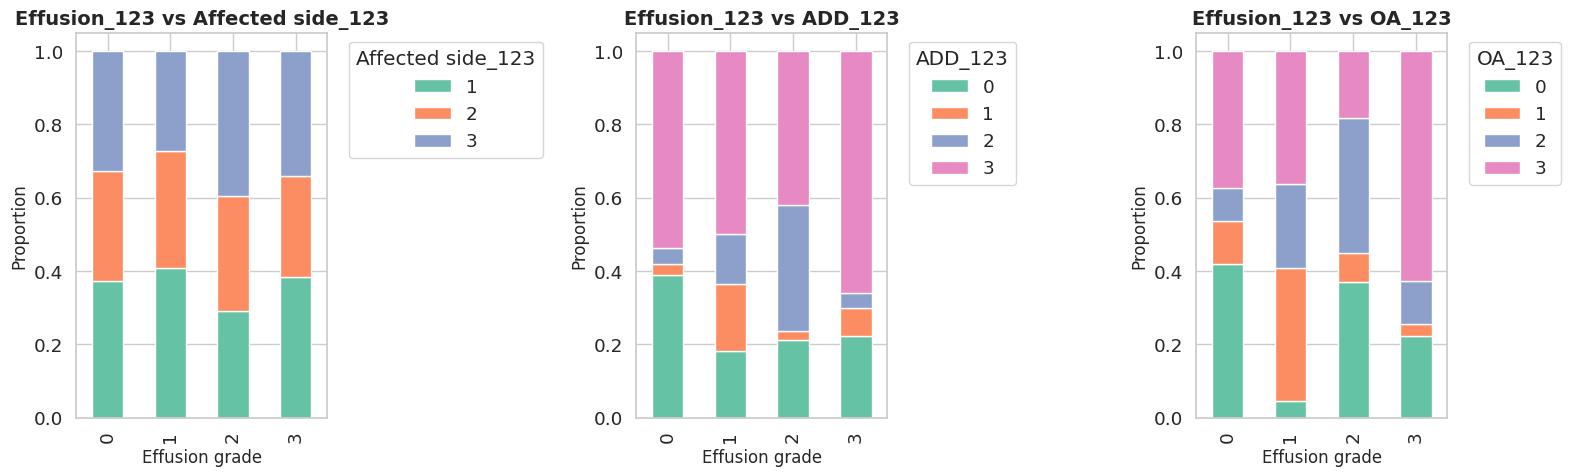

In [ ]:
sns.set(style="whitegrid", font_scale=1.2)

x_var = 'Effusion_123'
y_vars = ['Affected side_123', 'ADD_123', 'OA_123']

plt.figure(figsize=(16,5))

for i, y in enumerate(y_vars, 1):
    plt.subplot(1,3,i)

    ctab = pd.crosstab(df[x_var], df[y], normalize='index')
    ctab.plot(kind='bar', stacked=True, ax=plt.gca(),
              color=sns.color_palette("Set2", n_colors=ctab.shape[1]))

    plt.title(f"{x_var} vs {y}", fontsize=14, weight="bold")
    plt.xlabel("Effusion grade", fontsize=12)
    plt.ylabel("Proportion", fontsize=12)
    plt.legend(title=y, bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()
plt.show()


Heatmap

Effusion_123 vs Affected side_123: Chi2=1.66, p=0.948
Effusion_123 vs ADD_123: Chi2=42.19, p=0.000
Effusion_123 vs OA_123: Chi2=58.44, p=0.000


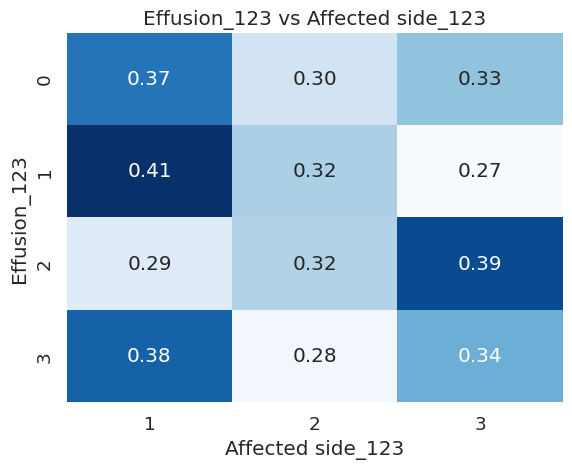

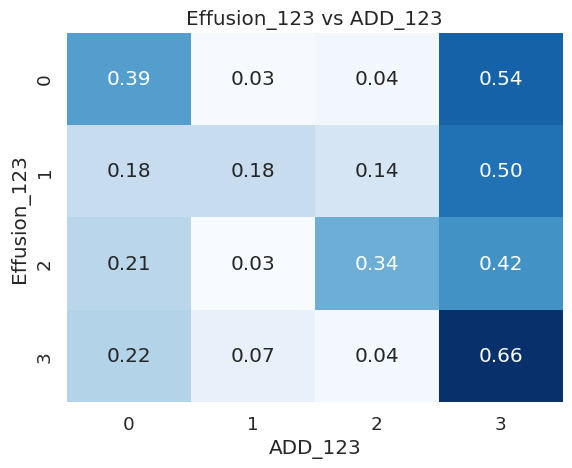

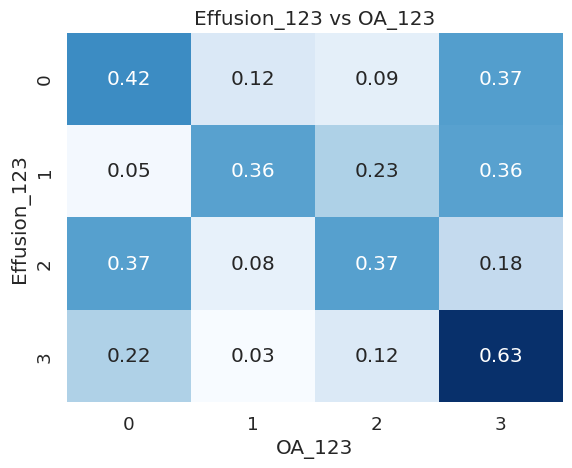

In [ ]:
import pandas as pd
from scipy.stats import chi2_contingency

for y in y_vars:
    ctab = pd.crosstab(df[x_var], df[y])
    chi2, p, dof, exp = chi2_contingency(ctab)
    print(f"{x_var} vs {y}: Chi2={chi2:.2f}, p={p:.3f}")

for y in y_vars:
    ctab = pd.crosstab(df[x_var], df[y], normalize='index')
    sns.heatmap(ctab, annot=True, cmap="Blues", cbar=False, fmt=".2f")
    plt.title(f"{x_var} vs {y}")
    plt.show()
